In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

In [4]:
def f(x):
    return x**3 - 3*x**2 - 9*x + 10

def f_prime(x):
    return 3*x**2 - 6*x - 9

def f_double_prime(x):
    return 6*x - 6

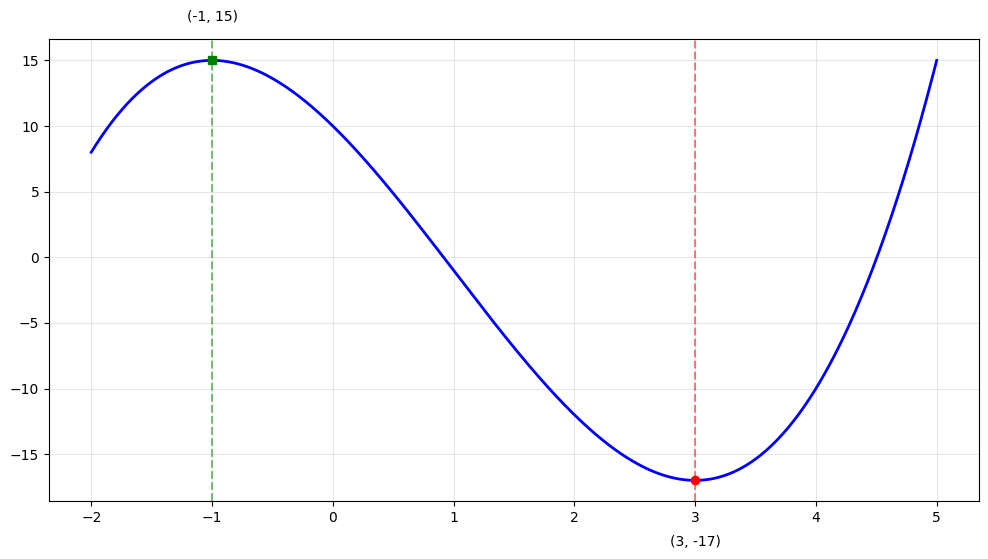

In [ ]:
x = np.linspace(-2, 5, 1000)
y = f(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y, 'b-', linewidth=2,)
plt.grid(True, alpha=0.3)

x_min = 3
y_min = f(x_min)
plt.plot(x_min, y_min, 'ro')
x_max = -1
y_max = f(x_max)
plt.plot(x_max, y_max, 'gs')

plt.axvline(x=3, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=-1, color='g', linestyle='--', alpha=0.5)
plt.text(3, f(3)-5, f'(3, {f(3)})', ha='center', fontsize=10)
plt.text(-1, f(-1)+3, f'(-1, {f(-1)})', ha='center', fontsize=10)

plt.show()


Итерация 1: a=2.000000, b=3.505000, x=2.752500
Итерация 2: a=2.747500, b=3.505000, x=3.126250
Итерация 3: a=2.747500, b=3.131250, x=2.939375
Итерация 4: a=2.934375, b=3.131250, x=3.032812
Итерация 5: a=2.934375, b=3.037812, x=2.986094
Итерация 6: a=2.981094, b=3.037812, x=3.009453
Итерация 7: a=2.981094, b=3.014453, x=2.997773
Итерация 8: a=2.992773, b=3.014453, x=3.003613
Итерация 9: a=2.992773, b=3.008613, x=3.000693
Итерация 10: a=2.992773, b=3.005693, x=2.999233
Итерация 11: a=2.994233, b=3.005693, x=2.999963
Итерация 12: a=2.994963, b=3.005693, x=3.000328
Итерация 13: a=2.994963, b=3.005328, x=3.000146
Итерация 14: a=2.994963, b=3.005146, x=3.000055
Итерация 15: a=2.994963, b=3.005055, x=3.000009
Итерация 16: a=2.994963, b=3.005009, x=2.999986
Итерация 17: a=2.994986, b=3.005009, x=2.999998
Итерация 18: a=2.994998, b=3.005009, x=3.000003
Итерация 19: a=2.994998, b=3.005003, x=3.000000
Итерация 20: a=2.994998, b=3.005000, x=2.999999
Итерация 21: a=2.994998, b=3.004999, x=2.999998
И

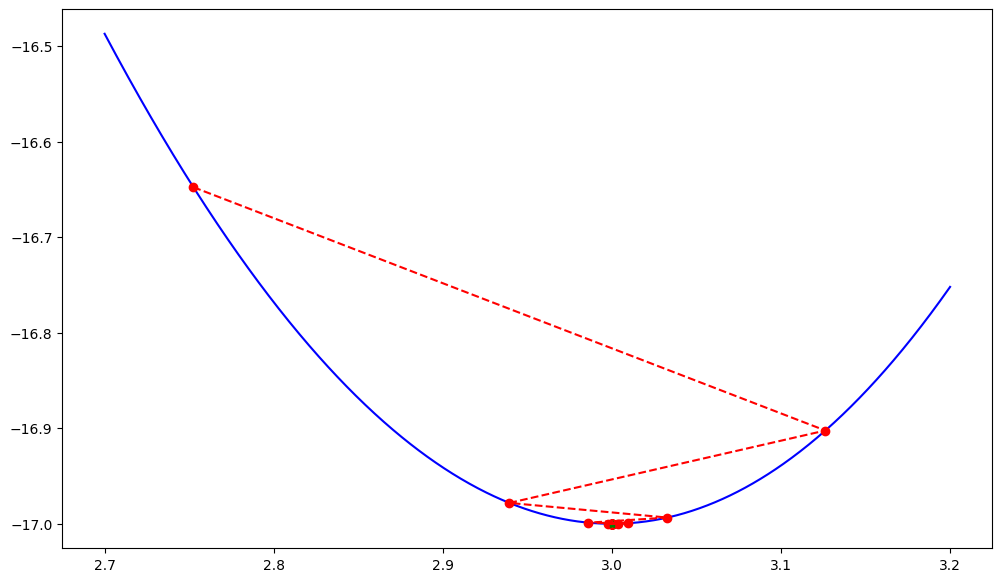

Количество итераций: 50
Приближение: x = 2.999998, f(x) = -17.000000
Точный минимум: x = 3.0000, f(x) = -17.0000
Погрешность: Δx = 2.08e-06


In [ ]:
def f(x):
    return x**3 - 3*x**2 - 9*x + 10

def dichotomy_method(a, b, delta=0.01, eps=1e-4, max_iter=100):
    x_iter = []
    iterations = 0
    
    while (b - a) > eps and iterations < max_iter:
        x1 = (a + b - delta) / 2
        x2 = (a + b + delta) / 2
        
        if f(x1) < f(x2):
            b = x2
        else:
            a = x1
        
        x_iter.append((a + b) / 2)
        iterations += 1
        
        print(f"Итерация {iterations}: a={a:.6f}, b={b:.6f}, x={(a+b)/2:.6f}")
    
    return x_iter, iterations

x_iter, iterations = dichotomy_method(2, 5, delta=0.01, eps=1e-4, max_iter=50)

#мин
x_exact = 3
y_exact = f(x_exact)

x_plot = np.linspace(2.7, 3.2, 1000)
y_plot = f(x_plot)
plt.figure(figsize=(12, 7))
plt.plot(x_plot, y_plot, 'b-')
plt.plot(x_iter, [f(x) for x in x_iter], 'ro')
plt.plot(x_exact, y_exact, 'g*')

#траектория
if len(x_iter) > 0:
    plt.plot(x_iter, [f(x) for x in x_iter], 'r--')

plt.show()

if len(x_iter) > 0:
    x_min = x_iter[-1]
    print(f"Приближение: x = {x_min:.6f}, f(x) = {f(x_min):.6f}")
    print(f"Точный минимум: x = {x_exact:.4f}, f(x) = {y_exact:.4f}")
    print(f"Погрешность = {abs(x_min - x_exact):.2e}")
else:
    print("Метод не сошелся")

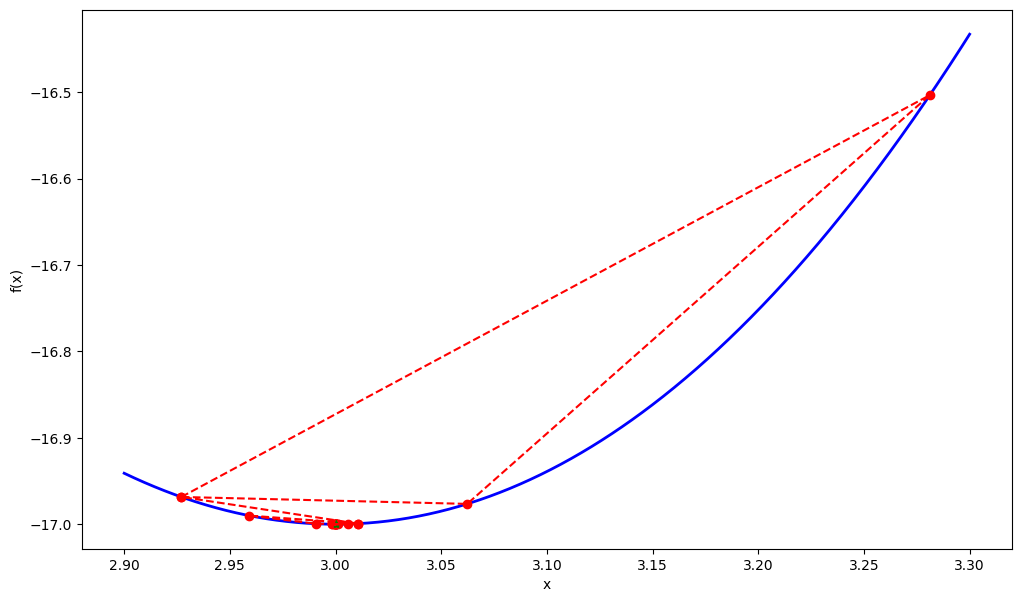

Количество итераций: 22
Приближение: x = 3.0000, f(x) = -17.0000
Точный минимум: x = 3.0000, f(x) = -17.0000
Погрешность = 1.86e-05


In [ ]:
def f(x):
    return x**3 - 3*x**2 - 9*x + 10

def golden_section(a, b, eps=1e-4):
    tau = (np.sqrt(5) - 1) / 2
    x_iter = []
    
    x1 = b - tau * (b - a)
    x2 = a + tau * (b - a)
    f1 = f(x1)
    f2 = f(x2)
    
    while (b - a) > eps:
        if f1 < f2:
            b = x2
            x2 = x1
            f2 = f1
            x1 = b - tau * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1 = x2
            f1 = f2
            x2 = a + tau * (b - a)
            f2 = f(x2)
        
        x_iter.append((a + b) / 2)
    
    return x_iter

x_iter = golden_section(2, 5, eps=1e-4)

#min
x_exact = 3
y_exact = f(x_exact)

x_plot = np.linspace(2.9, 3.3, 1000)
y_plot = f(x_plot)
plt.figure(figsize=(12, 7))
plt.plot(x_plot, y_plot, 'b-', linewidth=2, label=r'$f(x) = x^3 - 3x^2 - 9x + 10$')
plt.plot(x_iter, [f(x) for x in x_iter], 'ro')
plt.plot(x_exact, y_exact, 'g*')
plt.plot(x_iter, [f(x) for x in x_iter], 'r--') #траектория
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

x_min = x_iter[-1]
print(f"Количество итераций: {len(x_iter)}")
print(f"Приближение: x = {x_min:.4f}, f(x) = {f(x_min):.4f}")
print(f"Точный минимум: x = {x_exact:.4f}, f(x) = {y_exact:.4f}")
print(f"Погрешность = {abs(x_min - x_exact):.2e}")

Итерация 1: a=2.0000, b=5.0000, x_new=3.1250, f=-16.9043
Итерация 2: a=2.0000, b=5.0000, x_new=2.6306, f=-16.2317
Итерация 3: a=2.0000, b=5.0000, x_new=3.6194, f=-14.4606
Итерация 4: a=2.0000, b=5.0000, x_new=2.3741, f=-14.8946
Итерация 5: a=2.0000, b=5.0000, x_new=2.8871, f=-16.9250
Итерация 6: a=2.0000, b=5.0000, x_new=3.3383, f=-16.2748
Итерация 7: a=2.0000, b=5.0000, x_new=3.9005, f=-11.4041
Итерация 8: a=2.0000, b=5.0000, x_new=2.7685, f=-16.6909
Итерация 9: a=2.0000, b=5.0000, x_new=3.0058, f=-16.9998
Итерация 10: a=2.0000, b=5.0000, x_new=3.2229, f=-16.6909
Итерация 11: a=2.0000, b=5.0000, x_new=3.4536, f=-15.6720
Итерация 12: a=2.0000, b=5.0000, x_new=2.2272, f=-13.8785
Итерация 13: a=2.0000, b=5.0000, x_new=2.5209, f=-15.7329
Итерация 14: a=2.0000, b=5.0000, x_new=2.9475, f=-16.9836
Итерация 15: a=2.0000, b=5.0000, x_new=3.0641, f=-16.9751


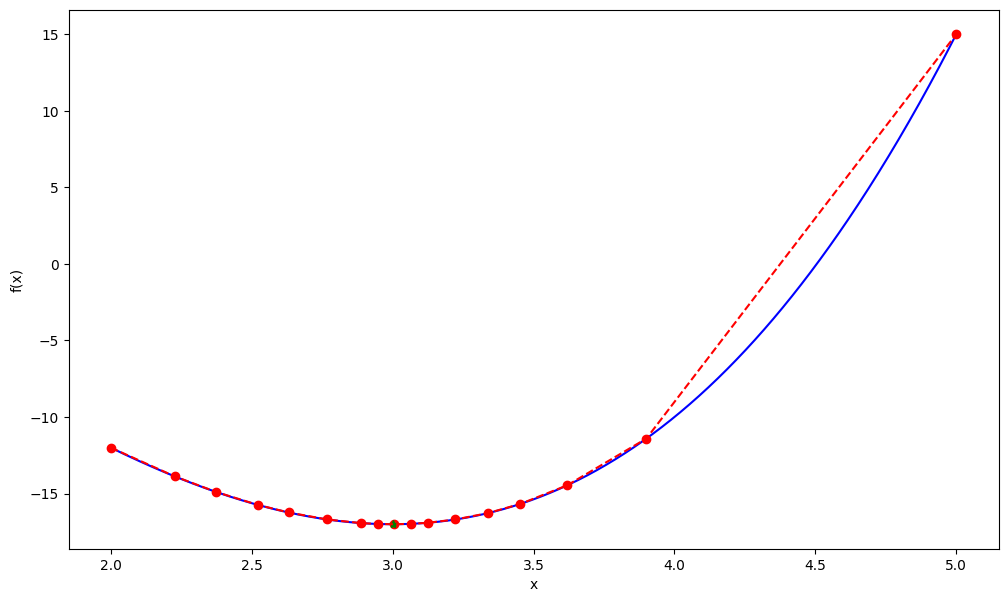

Итераций: 15
x_min = 3.005787, f(x_min) = -16.999799
Погрешность= 5.79e-03


In [ ]:
def f(x):
    return x**3 - 3*x**2 - 9*x + 10

def broken_line_method(a, b, L, eps=1e-2, max_iter=15):
    points = [(a, f(a)), (b, f(b))]
    x_iter = [a, b]
    
    iteration = 0
    while (b - a) > eps and iteration < max_iter:
        min_R = float('inf')
        best_interval = None
        
        for i in range(len(points) - 1):
            x_i, f_i = points[i]
            x_j, f_j = points[i+1]
            R = (f_i + f_j) / 2 - L / 2 * (x_j - x_i)
            
            if R < min_R:
                min_R = R
                best_interval = (i, x_i, x_j, f_i, f_j)
        
        i, x_i, x_j, f_i, f_j = best_interval
        x_new = (x_i + x_j) / 2 - (f_j - f_i) / (2 * L)
        x_new = np.clip(x_new, x_i, x_j)
        
        points.insert(i + 1, (x_new, f(x_new)))
        points.sort(key=lambda p: p[0])
        a, b = points[0][0], points[-1][0]
        x_iter.append(x_new)
        iteration += 1
        print(f"Итерация {iteration}: a={a:.4f}, b={b:.4f}, x_new={x_new:.4f}, f={f(x_new):.4f}")
    
    x_min = min(points, key=lambda p: p[1])[0]
    return x_min, x_iter, iteration
L = 36

x_min, x_iter, iterations = broken_line_method(2, 5, L, eps=1e-2, max_iter=15)
x_exact = 3

x_plot = np.linspace(2, 5, 1000)
y_plot = f(x_plot)
plt.figure(figsize=(12, 7))
plt.plot(x_plot, y_plot, 'b-')
plt.plot(x_iter, [f(x) for x in x_iter], 'ro')
plt.plot(x_exact, f(x_exact), 'g*')
sorted_idx = np.argsort(x_iter)
x_sorted = np.array(x_iter)[sorted_idx]
y_sorted = np.array([f(x) for x in x_iter])[sorted_idx]
plt.plot(x_sorted, y_sorted, 'r--')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

print(f"Итераций: {iterations}")
print(f"x_min = {x_min:.6f}, f(x_min) = {f(x_min):.6f}")
print(f"Погрешность= {abs(x_min - x_exact):.2e}")

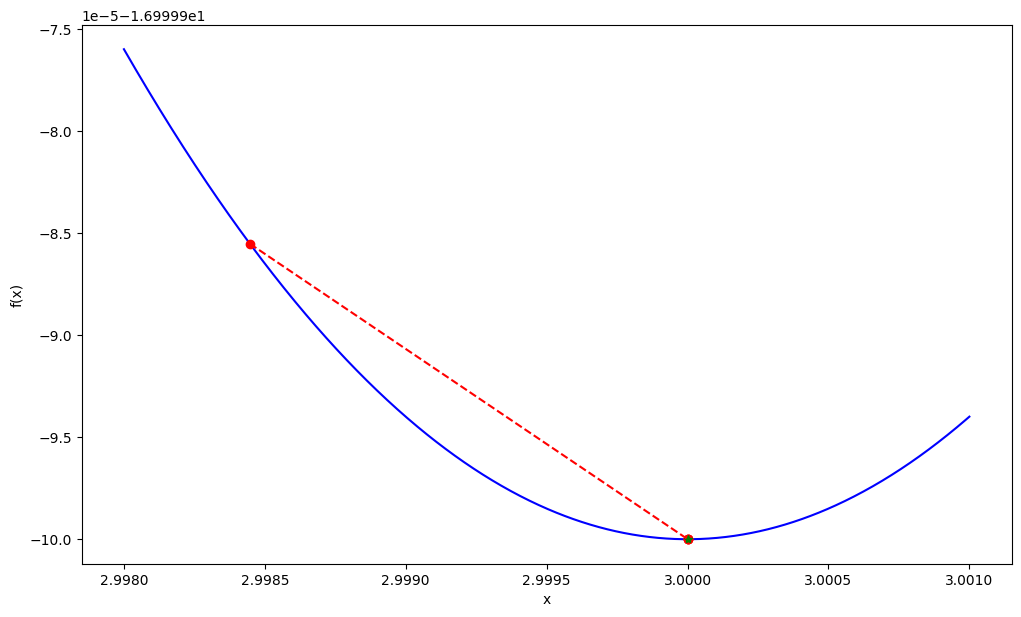

Количество итераций: 3
Приближение: x = 3.00000000, f(x) = -17.00000000


In [35]:
def f(x):
    return x**3 - 3*x**2 - 9*x + 10

def f_prime(x):
    return 3*x**2 - 6*x - 9

def f_double_prime(x):
    return 6*x - 6

def combined_method(a, b, eps1=1e-2, eps2=1e-8):
    tau = (np.sqrt(5) - 1) / 2 #step1
    while (b - a) > eps1:
        x1 = b - tau * (b - a)
        x2 = a + tau * (b - a)
        if f(x1) < f(x2):
            b = x2
        else:
            a = x1
    x0 = (a + b) / 2
    
    x = x0
    x_iter = [x0]
    
    for _ in range(20): #step 2
        x_next = x - f_prime(x) / f_double_prime(x)
        x_iter.append(x_next)
        if abs(x_next - x) < eps2:
            break
        x = x_next
    
    return x_next, x_iter

x_min, x_iter = combined_method(2, 5, eps1=1e-2, eps2=1e-8)

x_exact = 3

x_plot = np.linspace(2.998, 3.001, 1000)
y_plot = f(x_plot)
plt.figure(figsize=(12, 7))
plt.plot(x_plot, y_plot, 'b-')
plt.plot(x_iter, [f(x) for x in x_iter], 'ro')
plt.plot(x_exact, f(x_exact), 'g*')
plt.plot(x_iter, [f(x) for x in x_iter], 'r--') #trace
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

print(f"Количество итераций: {len(x_iter)-1}")
print(f"Приближение: x = {x_min:.8f}, f(x) = {f(x_min):.8f}")


x0 = 4:
  x_min = 3.00000000, f(x_min) = -17.00000000
  итераций = 5, погрешность = 0.00e+00

x0 = 2.5:
  x_min = 3.00000000, f(x_min) = -17.00000000
  итераций = 5, погрешность = 4.44e-16

x0 = 5:
  x_min = 3.00000000, f(x_min) = -17.00000000
  итераций = 6, погрешность = 0.00e+00


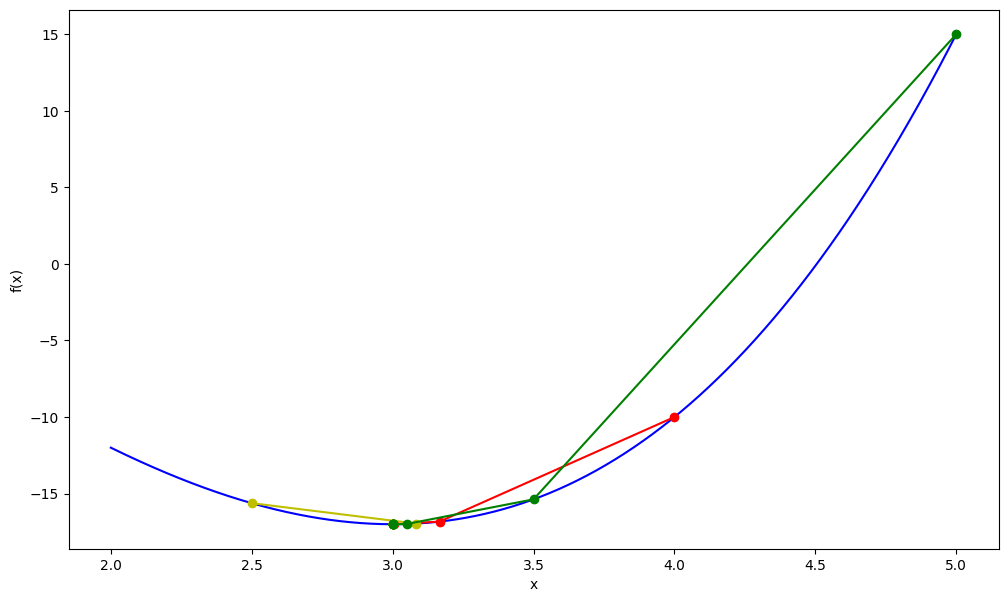

In [39]:
def f(x):
    return x**3 - 3*x**2 - 9*x + 10
def f_prime(x):
    return 3*x**2 - 6*x - 9
def f_double_prime(x):
    return 6*x - 6

def newton_method(x0, eps=1e-8, max_iter=10):
    x = x0
    x_iter = [x]
    
    for _ in range(max_iter):
        x_next = x - f_prime(x) / f_double_prime(x)
        x_iter.append(x_next)
        if abs(x_next - x) < eps:
            break
        x = x_next
    
    return x_next, x_iter

x_exact = 3
x0_values = [4, 2.5, 5]
colors = ['r', 'y', 'g']

x_plot = np.linspace(2, 5, 1000)
y_plot = f(x_plot)
plt.figure(figsize=(12, 7))
plt.plot(x_plot, y_plot, 'b-')
plt.plot(x_exact, f(x_exact), 'g*')
for x0, color in zip(x0_values, colors):
    x_min, x_iter = newton_method(x0)
    plt.plot(x_iter, [f(x) for x in x_iter], f'{color}o-')
    
    print(f"\nx0 = {x0}:")
    print(f"  x_min = {x_min:.8f}, f(x_min) = {f(x_min):.8f}")
    print(f"  итераций = {len(x_iter)-1}, погрешность = {abs(x_min - x_exact):.2e}")

plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()